<table style="width:100%; float:center; background-color:#FFFFFF" align="left">
<tr>
<td style="text-align:left; background-color:#FFFFFF"></td>
<td style="text-align:right; background-color:#FFFFFF"><div>
<image src="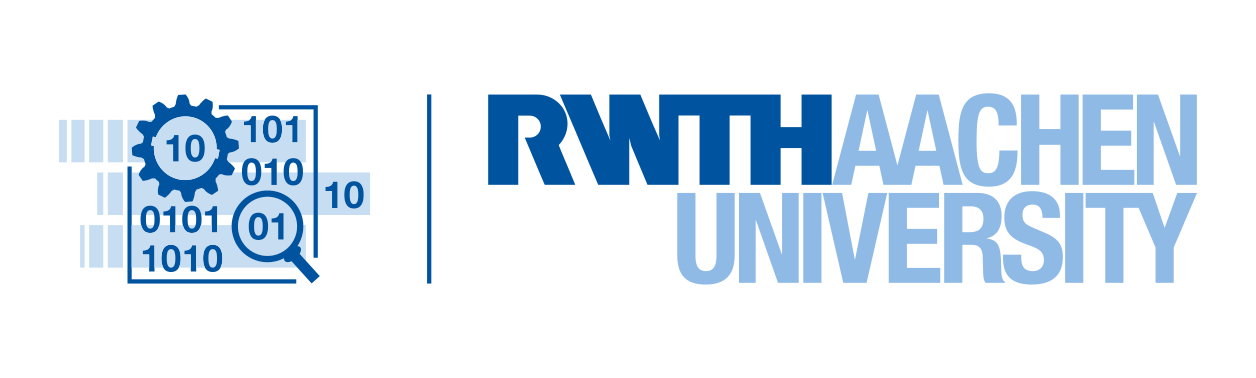" width="500">
    
</div>
</td></tr>
</table>

Prof. Dr. Sandra Geisler <br>
Anastasiia Belova, Soo-Yon Kim

May 26, 2025

<center>

<h1> Data Stream Management and Analysis <br />(Summer Term 2025)</h1>
    
<h1> Exercise 3</h1>
    
</center>

---
**Due until Monday, June 16 at 08:00 am.  
As solutions, please submit the filled-in Jupyter notebook to moodle.  
Please do _not_ submit handwritten solutions! Your solutions should be submitted in groups of 4 students.**  
Solutions to this exercise will be presented on Friday, June 20.

---

### Group members: [Luyang Huang, 466716], [Feiyu Wang, 460101], [Yansong Liu, 453322], [Xingjian Tian, 436949]
#### Insert all group members by double-clicking on this cell.

---

## How to fill in the assignment

For coding tasks, you will find code cells with parts marked with comments in capital letters, e.g.: `# ADD IMPLEMENTATION ...` or `# REPLACE ...`    
Here, insert the required code into that part.

For written tasks, you will find Markdown cells marked with: `Please replace this text with your answer.`  
Here, you can double-click to edit the cell and use [Markdown](https://markdown.de/) to format the answer.  
Mathematical expressions can be created via Latex. For this, enclose the expressions with \$.  


## Task 1 (SpaceSaving Algorithm - Properties) (5 pts)

SpaceSaving is a sketch algorithm which maintains in memory a set of at most k pairs (item, count), initialized with the first k distinct elements and their counts. 

When a new stream item arrives and if it already has an entry in the set, the item's count is incremented. If not, this item replaces the item with the lowest count, which is then incremented by 1. See also the SpaceSaving pseudocode in the lecture. 

The non-intuitive part is that this item inherits the counts of the element it evicts, even if this is its first occurrence. 
However, as the following claims show, the error is never too large, and can neither make a rare element look too frequent nor a true heavy hitter look too infrequent.  

Let $f_{t,x}$ be the absolute frequency of item x among the first t stream elements, and if x is in the sketch S at time t, let $count_t(x)$ be its associated count. The following are true for every item x and at all times t:

1. The value of the smallest counter $min$ is at most $t/k$.
2. If $x \in S$, then $f_{t,x} \le count_t(x) \le f_{t,x} + min$.
3. If $x \notin S$, then $f_{t,x} \le min$.  

For each statement, show that it holds. Please do so in your own words/with your own approach.  

(Hint for 1.: One possible way is to show first that it holds: $t=\sum_{x \in S} count_t(x)$ and argue from there.)

$min <= count_{t}(x)$ at any time for all $x \in S$, there are k counters and $t=\sum_{x \in S} count_t(x)$. So we have $min \times k \leq t$. Equivalently, $min \leq t/k$</br>

By definition of $f_{t,x}$, we have $f_{t,x} \leq count_{t}(x)$. If $x \notin S$ and we replace $(y,min)$ with $(x,min+1)$, then $count_{t}(x) \leq f_{t,x} + min$ given there are most $f_{t,x}$ operations like this.

If $x \notin S$, x might not be counted yet, then $f_{t,x} \leq min$. Otherwise, if $f_{t,x} > min$, then $x \in S$ which contradicts statement $x \notin S$.

<div class = "alert alert-success">

1. 

- To use $t=\sum_{x \in S} count_t(x)$ in your proof you need to proof it first -0.5pt

2. 

- It is not clear from the definition of $f_{t,x}$ that it is smaller or equal to $count_t(x)$. So you need to discuss two cases when arguing that $count_t(x) >= f_{t,x}$, i.e., the case in which x is always in S, and the case in which x was once in S but was later replaced by some other value, and then appears again at t. -1pt

3. Your reasoning is not clear enough i.e. you did not state the two cases clear enough. -1pt

- x has never been in S  and
- x has been in S before but has been evicted 

__2.5/5__

</div>

## Task 2 (Counting Distinct Elements) (4 pts)

In this task, we compare approaches for estimating the number of distinct elements in a stream.

Given are two streams on the alphabet {A,B,...,Z}:

stream $S1$: C, D, B, B, Z, B, B, R, T, S, X, R, D, U, E, B, R, T, Y, L, M, A, T, W

stream $S2$: T, B, B, R, W, B, B, T, T, E, T, R, R, T, E, M, W, T, R, M, M, W, B, W

1\. Sampling-based approach:  
For each $S1$ and $S2$, estimate the number of distinct elements by:  
- Sampling every third element of the stream (for $S1$: B, B, T, ...),
- counting the number of distinct elements in the sample,
- multiplying the sample by factor 3 (underlying assumption: 33% of the elements of a stream carry 33% of the distinct elements).  

a) Compare your results for $S1$ and $S2$ with their actual number of distinct elements.

b) Discuss whether this sampling-based algorithm is an appropriate estimator.

2\. Linear Counting:  
Consider the Linear Counting sketch from the lecture:

```text
1   Init(D, ρ):  
2       D is an upper bound on the number of distinct elements  
3       ρ > 0 is a load factor  
4       s ← D/ρ  
5       choose a hash function $h$ from items to {0, . . . , s − 1}  
6       build a bit vector B of size s  
7   Update(x):  
8       B[h(x)] ← 1 
9   Query():  
10      let w be the fraction of 0s in B
11      return s · ln(1/w)
```

Given are the constants $D=26, ρ=2$, as well as the following hash function:  
h(A)=0, h(B)=0,  
h(C)=1, h(D)=1,  
h(E)=2, h(F)=2,  
...,  
h(Y)=12, h(Z)=12.

a) Calculate the Linear Counting estimate for both $S1$ and $S2$.

b) Discuss the advantages of the sketch with regard to its efficiency and to its adaptability by comparing it to the sampling-based approach.

c) Discuss the draw-backs of the sketch with regard to required a-priori knowledge.

1. Sampling-based approach:</br>
   S1: B, B, T, R, E, T, M, W -> 6 distinct elements</br>
   Estimation: 18 distinct elements</br>
   Actual distinct elements: 15</br>
   S2: B, B, T, R, E, T, M, W -> 6 distinct elements</br>
   Estimation: 18 distinct elements</br>
   Actual distinct elements: 6</br>

   It is not appropriate method. Because assumption is not reliable without evidence or prior knowledge. It underestimates distinct elements in S1 and overestimates distinct elements in S2.<br>

2. Linear Counting:</br>
a)</br>
   S1: B[0] = B[1] = B[2] = B[5] = B[6] = B[8] = B[9] = B[10] = B[11] = B[12] = 1 -> w = 3 / 13</br>
   Estimation: 19</br>
   S2: B[0] = B[2] = B[6] = B[7] = B[9] = B[11] = 1 -> w = 7 / 13</br>
   Estimation: 8</br>
b)</br>
   It is less sensitive to random selected samples and uses fixed space that can be adjusted by load factor for computation.</br>
c)</br>
   If D is underestimated, number of distinct elements is also underestimated caused by more frequent hash collision. 

<div class = "alert alert-success">

__4/4__
</div>

## Task 3 (Exponential Histograms) (5 pts)

Consider the following bitstream:

| t     | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|-------|---|---|---|---|---|---|---|---|---|--- |--- |--- |
| Bits  | 1 | 1 | 0 | 1 | 1 | 0 | 1 | 0 | 1 | 1  | 1  | 0  |


1.\ Apply the exponential histogram algorithm from the lecture (Init, Update) to the following bit stream with sum as the aggregation operation. Make sure to note down what happens for each arriving element. Use k=3, W=10.

2.\ Which result would a query to the histogram return after t=12? How is the relative error?

1. 
| timestamp | Bucket | description |
| --- | --- | --- |
| 1 | $[1]_{t1}$ | Create new bucket with a capacity 1 |  
| 2 | $[1]_{t1}$ $[1]_{t2}$ | Create new bucket with a capacity 1 |  
| 3 | $[1]_{t1}$ $[10]_{t2}$ | Do nothing |
| 4 | $[1]_{t1}$ $[10]_{t2}$ $[1]_{t4}$ | Create new bucket with a capacity 1 | 
| 5 | $[110]_{t2}$ $[1]_{t4}$ $[1]_{t5}$  | Create new bucket with a capacity 1 and merge the two oldest buckets of capacity 1 |
| 6 | $[110]_{t2}$ $[1]_{t4}$ $[10]_{t5}$  | Do nothing. |
| 7 | $[110]_{t2}$ $[1]_{t4}$ $[10]_{t5}$ $[1]_{t7}$ | Create new bucket with a capacity 1 | 
| 8 | $[110]_{t2}$ $[1]_{t4}$ $[10]_{t5}$ $[10]_{t7}$ | Do nothing |
| 9 | $[110]_{t2}$ $[110]_{t5}$ $[10]_{t7}$ $[1]_{t9}$ | Create new bucket with a capacity 1 and merge the two oldest buckets of capacity 1 |
| 10 | $[110]_{t2}$ $[110]_{t5}$ $[10]_{t7}$ $[1]_{t9}$ $[1]_{t10}$ | Create new bucket with a capacity 1 |
| 11 | $[110]_{t2}$ $[110]_{t5}$ $[101]_{t9}$ $[1]_{t10}$ $[1]_{t11}$ | Create new bucket with a capacity 1 and merge the two oldest buckets of capacity 1 |
| 12 | $[110]_{t5}$ $[101]_{t9}$ $[1]_{t10}$ $[1]_{t11}$ | Remove bucket whose timestamp is $\leq$ t2 |

2. Sum of capacities of all existing buckets = 6, capacity of the oldest bucket = 2. Then query result is 5. Count reported by sketch is 7, so relative error = 16.67%.

<div class = "alert alert-success">

1. The bucket in timestep 12 is not removed, since the algorithm only checks this condition when a bit with value 1 arrived, which is not the case at t=12 -0.5pt

__4.5/5__
</div>

## Task 4 (Wavelet Synopsis) (6 pts)

Consider the following data elements of a data stream

S = [10, -3, 9, -4, 9, 1, -7, -2, 1, -3, 4, -18, 9, 2, 5, -6]

Create a wavelet synopsis for the given snapshot S using the method in the lecture, i.e.,

1\. Write down for each resolution level the resulting averages and coefficients.

| Level |                          Averages                          |         Coefficients          |
| :-:|:----------------------------------------------------------:|:-----------------------------:|
| 4 | [10, -3, 9, -4, 9, 1, -7, -2, 1, -3, 4, -18, 9, 2, 5, -6] | - |
| 3 | [3.5, 2.5, 5, -4.5, -1, -7, 5.5, -0.5] | [6.5, 6.5, 4, -2.5, 2, 11, 3.5, 5.5] |
| 2 | [3, 0.25, -4, 2.5] | [0.5, 4.75, 3, 3] |
| 1 | [1.625, -0.75] | [1.375, -3.25] |
| 0 | 0.4375 | [1.1875] |


2\. Create the synopsis based on the normalized elements. Assume, that you have 29 bytes of memory available for the synopsis and a coefficient can bestored with 6 bytes.

$W_A = [0.4375, 1.1875, 1.375, -3.25, 0.5, 4.75, 3, 3, 6.5, 6.5, 4, -2.5, 2, 11, 3.5, 5.5]$

After elements are normalizaed, we have
$W_{A-norm} = [1.75, 4.75, 2.75\sqrt2, -6.5\sqrt2, 1, 9.5, 6, 6, 6.5\sqrt2, 6.5\sqrt2, 4\sqrt2, -2.5\sqrt2, 2\sqrt2, 11\sqrt2, 3.5\sqrt2, 5.5\sqrt2]$

Because we can store at most 4 elements, synopsis is $[11\sqrt2, 6.5\sqrt2, 6.5\sqrt2, -6.5\sqrt2]$


3\. Draw the error tree (incl. -, + signs) and write down the reconstruction path for element $d_{9}$.

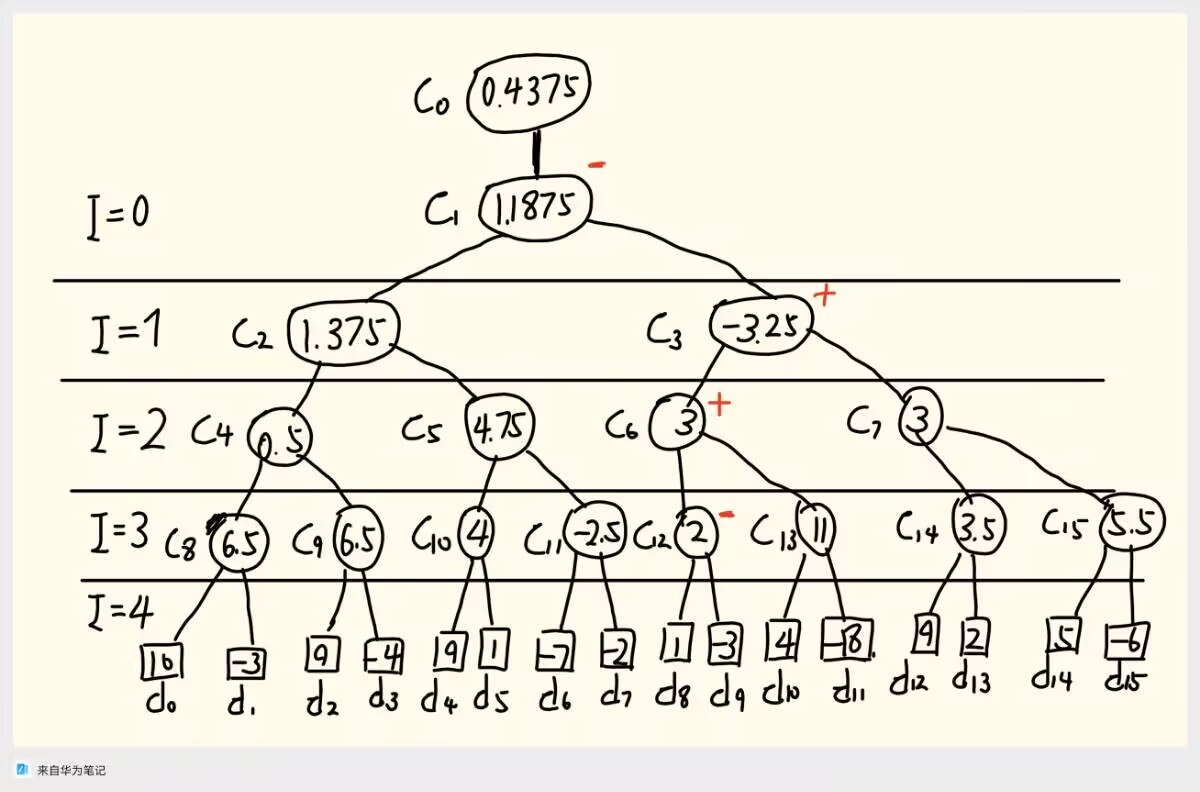


4\. Discuss if the approximation is additive or multiplicative.



The approximation is additive. Here we only select certain number of the largest coefficients, which only guarantees total error is small rather than percentages of error.

<div class = "alert alert-success">

3. Reconstruction path needs to be explicitly written down -0.5pt

4. Your reasoning does not clearly explain why the approximation is additive -1pt

__4.5/6__
</div>